#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings('ignore')

import time

#### Import Datasets

In [2]:
%store -r Set1_X_Train
%store -r Set1_X_Test

%store -r Set1_y_Train
%store -r Set1_y_Test

#### XGBoost Regression(All Columns)

In [3]:
start = time.time()

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

xgb_reg = xgb.XGBRegressor()

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2, 1],  
    'max_depth': [3, 5, 7],               
    'min_child_weight': [1, 3, 5],         
    'gamma': [0, 0.1, 0.2],               
    'objective': ['reg:squarederror']      
}


grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(Set1_X_Train, Set1_y_Train_array)
end_grid_search = time.time()

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_xgb_reg = xgb.XGBRegressor(learning_rate=best_params['learning_rate'],
                                 max_depth=best_params['max_depth'],
                                 min_child_weight=best_params['min_child_weight'],
                                 gamma=best_params['gamma'])

best_xgb_reg.fit(Set1_X_Train, Set1_y_Train_array)
end_train = time.time()  

xgb_reg_pred_train = best_xgb_reg.predict(Set1_X_Train)
end_predict_train = time.time()

xgb_reg_pred_test = best_xgb_reg.predict(Set1_X_Test)
end_predict_test = time.time()

xgb_reg_pred_train_int = xgb_reg_pred_train.astype(int)
xgb_reg_pred_test_int = xgb_reg_pred_test.astype(int)

Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'objective': 'reg:squarederror'}


#### XGBoost Evaluation 

In [4]:
# Mean Squared Error
mse_train_xgb = mean_squared_error(Set1_y_Train_array, xgb_reg_pred_train_int)
mse_test_xgb = mean_squared_error(Set1_y_Test_array, xgb_reg_pred_test_int)

# Root Mean Squared Error
rmse_train_xgb = np.sqrt(mse_train_xgb)
rmse_test_xgb = np.sqrt(mse_test_xgb)

# Mean Absolute Error
mae_train_xgb = mean_absolute_error(Set1_y_Train_array, xgb_reg_pred_train_int)
mae_test_xgb = mean_absolute_error(Set1_y_Test_array, xgb_reg_pred_test_int)

# R2 Score
r2_train_xgb = r2_score(Set1_y_Train_array, xgb_reg_pred_train_int)
r2_test_xgb = r2_score(Set1_y_Test_array, xgb_reg_pred_test_int)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict_train - end_train
time_predict_test = end_predict_test - end_predict_train
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_xgb)
print("Root Mean Squared Error:", rmse_train_xgb)
print("Mean Absolute Error:", mae_train_xgb)
print("R-squared Score:", r2_train_xgb)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_xgb)
print("Root Mean Squared Error:", rmse_test_xgb)
print("Mean Absolute Error:", mae_test_xgb)
print("R-squared Score:", r2_test_xgb)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 1630.826959429984
Root Mean Squared Error: 40.38349860314215
Mean Absolute Error: 28.76898841549125
R-squared Score: 0.6562599227766994

--Testing Set Evaluation--
Mean Squared Error: 1035.09
Root Mean Squared Error: 32.17281461109674
Mean Absolute Error: 23.19
R-squared Score: 0.40059747418102665

--Fit, Training Times--
Time for grid search: 109.58 seconds
Time to fit: 0.07 seconds
Time to predict (train set): 0.01 seconds
Time to predict (test set): 0.00 seconds
Total Time: 109.66 seconds


#### Plot Evaluation Results

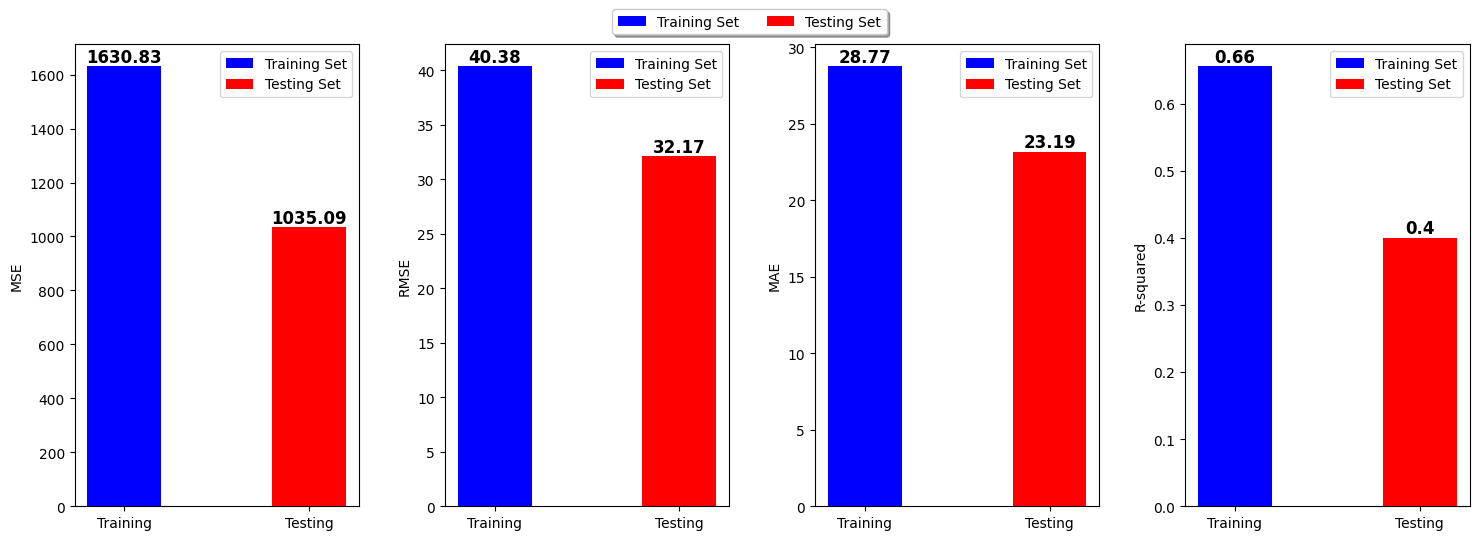

In [5]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics = [mse_train_xgb, rmse_train_xgb, mae_train_xgb, r2_train_xgb]
test_metrics = [mse_test_xgb, rmse_test_xgb, mae_test_xgb, r2_test_xgb]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

##### Plot Predicted vs Actual Values

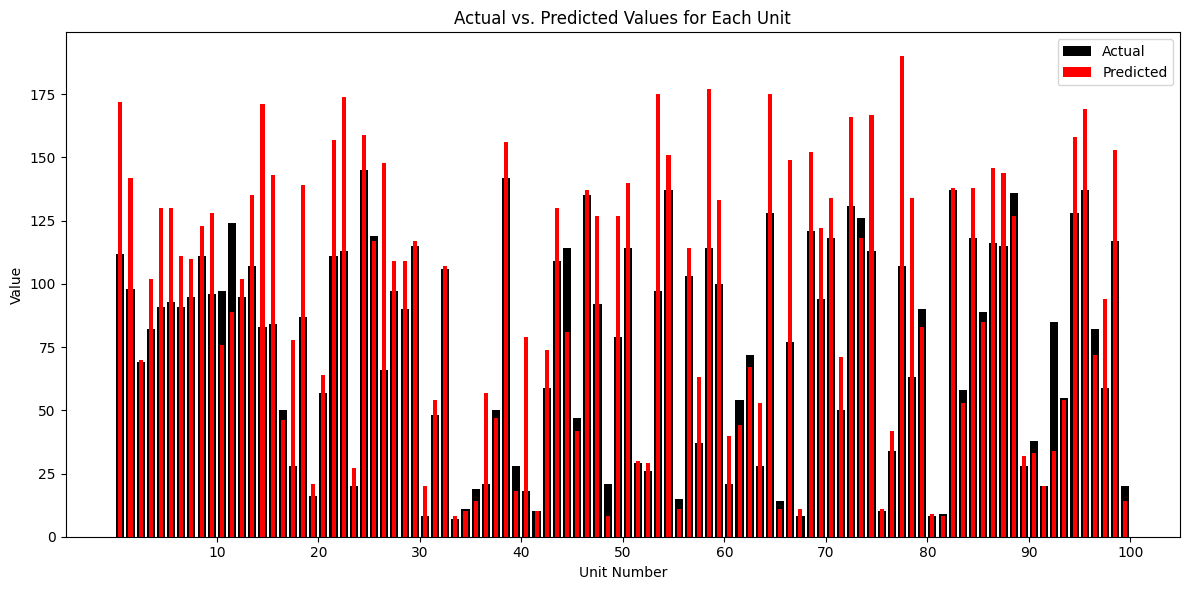

In [6]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(xgb_reg_pred_test_int)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

#### Random Forest Regressor (Dropped Constant, Highly Related Features, Applied Upper RUL Limit)

##### Import Dataset

In [7]:
%store -r FD1_X_Train
%store -r FD1_X_Test

%store -r FD1_y_Train
%store -r FD1_y_Test

#### XGBoost Regressor

In [8]:
start = time.time()

FD1_y_Train_array = FD1_y_Train.values.ravel()
FD1_y_Test_array = FD1_y_Test.values.ravel()

xgb_reg = xgb.XGBRegressor()

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2, 1],  
    'max_depth': [3, 5, 7],                
    'min_child_weight': [1, 3, 5],         
    'gamma': [0, 0.1, 0.2],                
    'objective': ['reg:squarederror']      
}


grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(FD1_X_Train, FD1_y_Train_array)
end_grid_search = time.time()

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_xgb_reg_new = xgb.XGBRegressor(learning_rate=best_params['learning_rate'],
                                 max_depth=best_params['max_depth'],
                                 min_child_weight=best_params['min_child_weight'],
                                 gamma=best_params['gamma'])

best_xgb_reg_new.fit(FD1_X_Train, FD1_y_Train_array)
end_train = time.time()  

xgb_new_pred_train = best_xgb_reg_new.predict(FD1_X_Train)
end_predict_train = time.time()

xgb_new_pred_test = best_xgb_reg_new.predict(FD1_X_Test)
end_predict_test = time.time()

Best Parameters: {'gamma': 0, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 5, 'objective': 'reg:squarederror'}


#### XGBoost Evaluation

In [9]:
# Mean Squared Error
mse_train_xgb_new = mean_squared_error(FD1_y_Train_array, xgb_new_pred_train)
mse_test_xgb_new = mean_squared_error(FD1_y_Test_array, xgb_new_pred_test)

# Root Mean Squared Error
rmse_train_xgb_new = np.sqrt(mse_train_xgb_new)
rmse_test_xgb_new = np.sqrt(mse_test_xgb_new)

# Mean Absolute Error
mae_train_xgb_new = mean_absolute_error(FD1_y_Train_array, xgb_new_pred_train)
mae_test_xgb_new = mean_absolute_error(FD1_y_Test_array, xgb_new_pred_test)

# R2 Score
r2_train_xgb_new = r2_score(FD1_y_Train_array, xgb_new_pred_train)
r2_test_xgb_new = r2_score(FD1_y_Test_array, xgb_new_pred_test)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict_train - end_train
time_predict_test = end_predict_test - end_predict_train
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_xgb_new)
print("Root Mean Squared Error:", rmse_train_xgb_new)
print("Mean Absolute Error:", mae_train_xgb_new)
print("R-squared Score:", r2_train_xgb_new)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_xgb_new)
print("Root Mean Squared Error:", rmse_test_xgb_new)
print("Mean Absolute Error:", mae_test_xgb_new)
print("R-squared Score:", r2_test_xgb_new)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds\n")

%store mse_test_xgb_new
%store rmse_test_xgb_new
%store mae_test_xgb_new
%store r2_test_xgb_new

--Training Set Evaluation--
Mean Squared Error: 262.15820717810357
Root Mean Squared Error: 16.191300354761616
Mean Absolute Error: 11.280226535447627
R-squared Score: 0.8610936284505653

--Testing Set Evaluation--
Mean Squared Error: 328.09757304711763
Root Mean Squared Error: 18.113463861092875
Mean Absolute Error: 13.652429189682007
R-squared Score: 0.8100044305330769

--Fit, Training Times--
Time for grid search: 97.34 seconds
Time to fit: 0.09 seconds
Time to predict (train set): 0.01 seconds
Time to predict (test set): 0.00 seconds
Total Time: 97.44 seconds

Stored 'mse_test_xgb_new' (float64)
Stored 'rmse_test_xgb_new' (float64)
Stored 'mae_test_xgb_new' (float64)
Stored 'r2_test_xgb_new' (float64)


#### Plot Evaluation Metrics

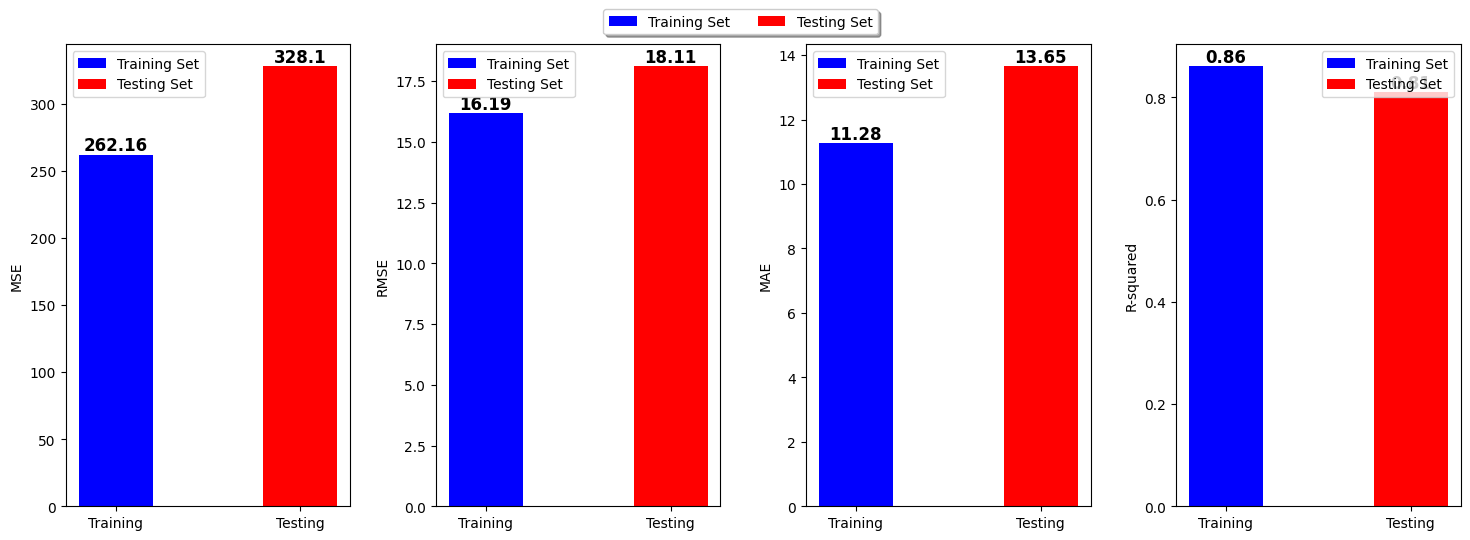

In [10]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared']
train_metrics = [mse_train_xgb_new, rmse_train_xgb_new, mae_train_xgb_new, r2_train_xgb_new]
test_metrics = [mse_test_xgb_new, rmse_test_xgb_new, mae_test_xgb_new, r2_test_xgb_new]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

#### Plot Actual vs Predicted Values

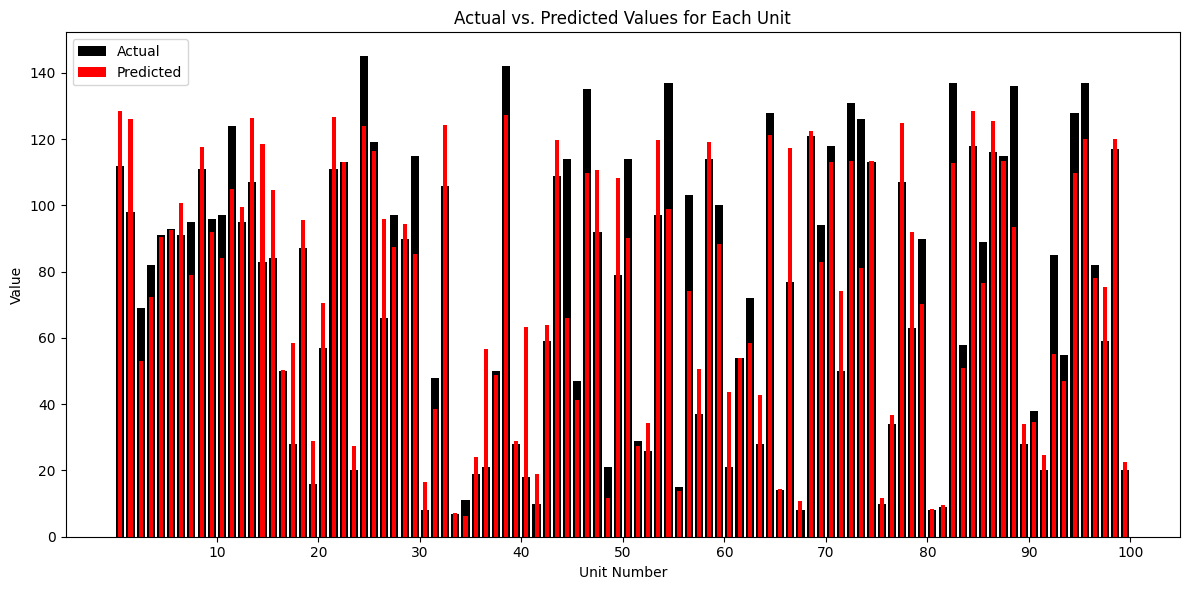

In [11]:
num_units = len(FD1_y_Test_array)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(FD1_y_Test_array)
predicted_values = np.squeeze(xgb_new_pred_test)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

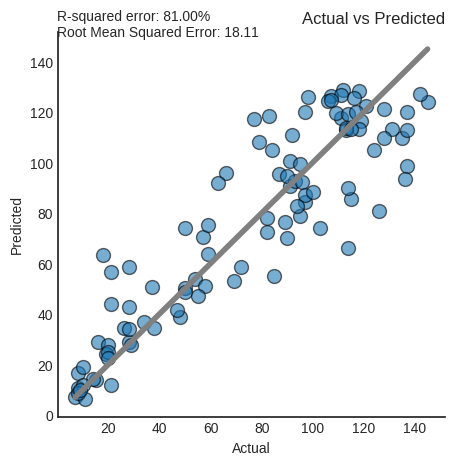

In [12]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=5,5 

fig,ax = plt.subplots()
plt.title('Actual vs Predicted', loc='right')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=FD1_y_Test_array,
                y=xgb_new_pred_test,
                s=100,
                alpha=0.6,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(FD1_y_Test_array),max(FD1_y_Test_array)],
             y=[min(FD1_y_Test_array),max(FD1_y_Test_array)],
             linewidth=4,
             color='gray',
             ax=ax)

plt.annotate(text=('R-squared error: '+ "{:.2%}".format(best_xgb_reg_new.score(FD1_X_Test,FD1_y_Test_array)) +'\n' +
                  'Root Mean Squared Error: '+ "{:.2f}".format(mean_squared_error(FD1_y_Test_array,xgb_new_pred_test,squared=False))),
             xy=(0,150),
             size='medium')

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()

##### Last 5 Cycles from X_Test

In [13]:
%store -r Last_5_X_Test

In [14]:
start = time.time()

FD1_y_Train_array = FD1_y_Train.values.ravel()
FD1_y_Test_array = FD1_y_Test.values.ravel()

xgb_reg = xgb.XGBRegressor()

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2, 1],  
    'max_depth': [3, 5, 7],                
    'min_child_weight': [1, 3, 5],         
    'gamma': [0, 0.1, 0.2],                
    'objective': ['reg:squarederror']      
}


grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(FD1_X_Train, FD1_y_Train_array)
end_grid_search = time.time()

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_xgb_reg_new = xgb.XGBRegressor(learning_rate=best_params['learning_rate'],
                                     max_depth=best_params['max_depth'],
                                     min_child_weight=best_params['min_child_weight'],
                                     gamma=best_params['gamma'],
                                     objective='reg:squarederror')


best_xgb_reg_new.fit(FD1_X_Train, FD1_y_Train_array)
end_train = time.time()  

xgb_new_pred_train = best_xgb_reg_new.predict(FD1_X_Train)
end_predict_train = time.time()

xgb_new_pred_test = best_xgb_reg_new.predict(Last_5_X_Test)
end_predict_test = time.time()

Best Parameters: {'gamma': 0, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 5, 'objective': 'reg:squarederror'}


In [15]:
xgb_new_pred_test_reshaped = xgb_new_pred_test.reshape(-1, 5)
average_rul_per_group = np.mean(xgb_new_pred_test_reshaped, axis=1)

In [16]:
# Mean Squared Error
mse_train_xbg_new = mean_squared_error(FD1_y_Train_array, xgb_new_pred_train)
mse_test_xgb_new = mean_squared_error(FD1_y_Test_array, average_rul_per_group)

# Root Mean Squared Error
rmse_train_xgb_new = np.sqrt(mse_train_xgb_new)
rmse_test_xgb_new = np.sqrt(mse_test_xgb_new)

# Mean Absolute Error
mae_train_xgb_new = mean_absolute_error(FD1_y_Train_array, xgb_new_pred_train)
mae_test_xgb_new = mean_absolute_error(FD1_y_Test_array, average_rul_per_group)

# R2 Score
r2_train_xgb_new = r2_score(FD1_y_Train_array, xgb_new_pred_train)
r2_test_xgb_new = r2_score(FD1_y_Test_array, average_rul_per_group)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict_train - end_train
time_predict_test = end_predict_test - end_predict_train
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_xgb_new)
print("Root Mean Squared Error:", rmse_train_xgb_new)
print("Mean Absolute Error:", mae_train_xgb_new)
print("R-squared Score:", r2_train_xgb_new)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_xgb_new)
print("Root Mean Squared Error:", rmse_test_xgb_new)
print("Mean Absolute Error:", mae_test_xgb_new)
print("R-squared Score:", r2_test_xgb_new)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 262.15820717810357
Root Mean Squared Error: 16.191300354761616
Mean Absolute Error: 11.280226535447627
R-squared Score: 0.8610936284505653

--Testing Set Evaluation--
Mean Squared Error: 346.08353390950856
Root Mean Squared Error: 18.603320507627355
Mean Absolute Error: 13.698601007461548
R-squared Score: 0.799589074988923

--Fit, Training Times--
Time for grid search: 80.24 seconds
Time to fit: 0.08 seconds
Time to predict (train set): 0.01 seconds
Time to predict (test set): 0.00 seconds
Total Time: 80.33 seconds
